<a href="https://colab.research.google.com/github/ajitesh68/machine-learning-practice-/blob/main/TF002_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INRODUCTION TO REGRESSION WITH NEURAL NETWORKS


there are many definition for a regression prblm but in our case we are going other combination of variables , even shorter .... predicting a number

In [ ]:
#IMPORT tensorflow
import tensorflow as tf
print(tf.__version__)

2.18.0


Creating data to view and fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#crate features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0], dtype=float)

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0], dtype=float)

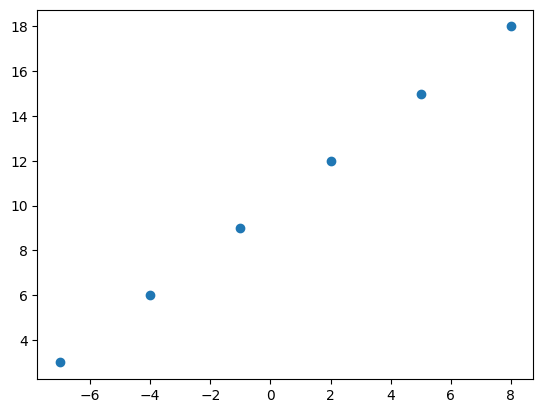

In [ ]:
plt.scatter(x,y)

In [ ]:
y == x+10

array([ True,  True,  True,  True,  True,  True])

Input and Output shapes

In [ ]:
#create a demo tensor for our houseing prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])

In [ ]:
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
x[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [ ]:
x[0].ndim

0

In [ ]:
x[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
#convert numpy arrays into tensors with dtype float 32
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)

In [ ]:
x , y


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape
#there is no shape as there is single value or scalar value

(TensorShape([]), TensorShape([]))

Steps in creating a model with TensorFlow

1. Creating a model - define the i/p and o/p layers , as well as the hidden layers of a deep learning model

2. Comppiling a model - define a loss fnc (in other words, the fnc which tells our model how wrong our model how wrong it is ) and optimizer (tells our model how to improve the patterns its learning ) and evaluation metrics (what we can use to interpret the performance of our model).

3. Fitting a model- letting the model try to find patterns between x & y (features and labels)

In [ ]:
#Set random seed
tf.random.set_seed

#1. create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])# mae are short for mean absolute error
              #sgd is short for stochastic gradient descent

#3. Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 9.8405 - mae: 9.8405
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 9.8280 - mae: 9.8280
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 9.8155 - mae: 9.8155
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 9.8030 - mae: 9.8030
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 9.7905 - mae: 9.7905


In [ ]:
#check out x and y
x , y

(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [ ]:
#Try add make prediction using our model
import numpy as np

y_pred = model.predict(np.array([[17.0]]))  # double brackets to make it 2D
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
[[22.897175]]


In [ ]:
y_pred + 10   # mae: 9.8731 hence we our adding 10 to y predicted

array([[32.897175]], dtype=float32)

Improving our model

Steps we can improve our model, by altering the steps we took to create a model

1. Create a model -- here we might add more layersm increase the number of hidden units (all called neurons) within each of the hidden layers , change the activation fnc of each layer

2. "Compiling a model" -- here we might change the optimization fnc or perhaps the "learning rate" of the optimization fnc

3. "Fitting a model" -- here we might fit a model for more ""epochs"" (leave it training for longer) or on more data (give the model more example to learn from).

In [ ]:
#higher the learning rate the more model pushes to improve at every step and lower the learning rate
# the model take lower steps to improve the model

In [ ]:
import numpy as np

# If x was like this:
# x = [1.0, 2.0, 3.0, 4.0]

# Do this instead:
x = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([2.0, 4.0, 6.0, 8.0])  # keep y as 1D


In [ ]:
#Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#3. Fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 5.6842 - mae: 5.6842
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.6117 - mae: 5.6117
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 5.5392 - mae: 5.5392
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 5.4667 - mae: 5.4667
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 5.3942 - mae: 5.3942
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 5.3217 - mae: 5.3217
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 5.2492 - mae: 5.2492
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 5.1767 - mae: 5.1767
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.1042 - mae: 5.1042
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 5.0317 - mae: 5.0317
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 4.9592 - mae: 4.9592
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4.8867 - mae: 4.8867
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

In [ ]:
#Remind ourselves of the data
x,y


(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [ ]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([[30.897375]], dtype=float32)

In [ ]:
#Let's see if we can make another to improve our model

#create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation= None),
    tf.keras.layers.Dense(1)
])

#2 . Compile the model
model.compile(loss ="mae",
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])


#fit the model
model.fit(x,y,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 4.2316 - mae: 4.2316
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.1809 - mae: 4.1809
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.1302 - mae: 4.1302
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 4.0794 - mae: 4.0794
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 4.0285 - mae: 4.0285
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3.9776 - mae: 3.9776
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 3.9266 - mae: 3.9266
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.8755 - mae: 3.8755
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 3.8243 - mae: 3.8243
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 3.7731 - mae: 3.7731
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.7218 - mae: 3.7218
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3.6704 - mae: 3.6704
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step 

In [ ]:
#Remind ourselves of the data
x,y

(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [ ]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[30.408653]], dtype=float32)

Common Ways To Improve the Deep Model

1. Adding The Layers
2. Increase the number of hidden units
3. Change the activation fnc
4. Change the optimization fnc
5. Change the learning rate(potentially the most imp hyperparameter of many diff neural networks)
6. Fitting more data
7. Fitting for longer



Evaluating a Model

In practice, a typical workflow you will go through while building a neural networks is:

Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it....

When it comes to evaluation.... there are 3 words you should memorize:

"Visualize, Visualize , Visualize"

It's good idea to visualize:

* the data we are working with? What does it look like ?
* The model itself - What does our model look like?
* The training of a model how does a model perform while learn
* The prediction of a model how does a prediction of a model line up against the ground truth ( the original labels)?

In [ ]:
#Make a bigger dataset  most probably for a good prediction or training

x  = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
#we want our model to learn this formula
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

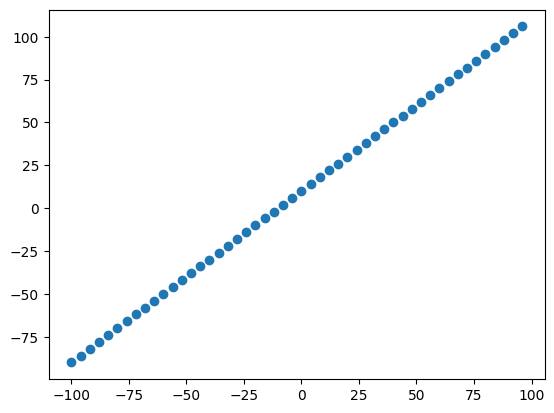

In [ ]:
#visulaize our data
import matplotlib.pyplot as plt
plt.scatter(x,y)


# There are 3 sets ..........

**Training set** :- The model learn from this data , typically contains 80% of the the total dataset available

**Validation dataset** :- The model gets tuned on this data , typically contains 10%-15% of the the total dataset available

**Testing dataset** :- The model gets test on this data , typically contains 10%-15% of the the total dataset available

In [ ]:
len(x)

50

In [ ]:
#Split the data into training and testing dataset

x_train = x[:40]#80% of the data is been given for training from 1-40     #first 40 are training samples
x_test = x[40:]#20% of the data is been given for testing from 41-50

y_train = x[:40]
y_test = x[40:]

In [ ]:
len(x_test), len(x_train), len(y_test), len(y_train)

(10, 40, 10, 40)

**Visualizing the predictions**
Now we've got a trained model, let's visualize some predictions.

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of y_test vs. y_pred (ground truth vs. predictions).

First, we'll make some predictions on the test data (X_test), remember the model has never seen the test data.

In [ ]:
# Make predictions
y_preds = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [ ]:

# View the predictions
y_preds

array([[105.50063 ],
       [112.48595 ],
       [119.471245],
       [126.45654 ],
       [133.44185 ],
       [140.42712 ],
       [147.41245 ],
       [154.39774 ],
       [161.38304 ],
       [168.36833 ]], dtype=float32)

In [ ]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

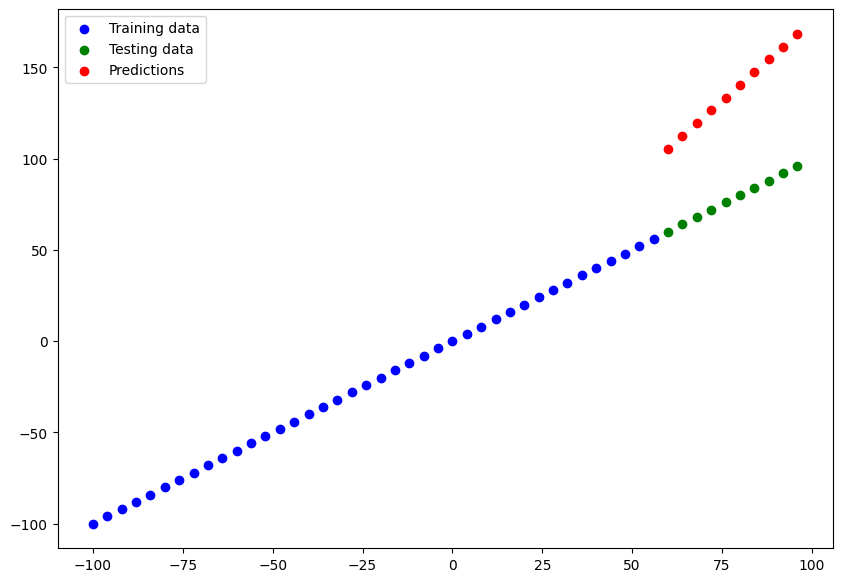

In [ ]:
plot_predictions(train_data=x_train,
                 train_labels=y_train,
                 test_data=x_test,
                 test_labels=y_test,
                 predictions=y_preds)

In [ ]:
def mae(y_test, y_pred):
  """
  Calculuates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.MAE(y_test,y_pred)

def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  return tf.metrics.MSE(y_test,y_pred)

**Running experiments to improve a model**

After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:

**Get more data** - get more examples for your model to train on (more opportunities to learn patterns).

**Make your model larger (use a more complex model)** - this might come in the form of more layers or more hidden units in each layer.

**Train for longer** - give your model more of a chance to find the patterns in the data.

Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:

model_1 - same as original model, 1 layer, trained for 100 epochs.
model_2 - 2 layers, trained for 100 epochs.
model_3 - 2 layers, trained for 500 epochs.
**Build model_1**

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 89.4237 - mae: 89.4237
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 53.7122 - mae: 53.7122
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 18.0007 - mae: 18.0007
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 14.1011 - mae: 14.1011
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 12.0207 - mae: 12.0207
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 9.9404 - mae: 9.9404   
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 7.8600 - mae: 7.8600
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 5.7797 - mae: 5.7797
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.6993 - mae: 3.6993
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 2.8659 - mae: 2.8659
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 3.6992 - mae: 3.6992 
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2.8660 - mae: 2.8660 
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


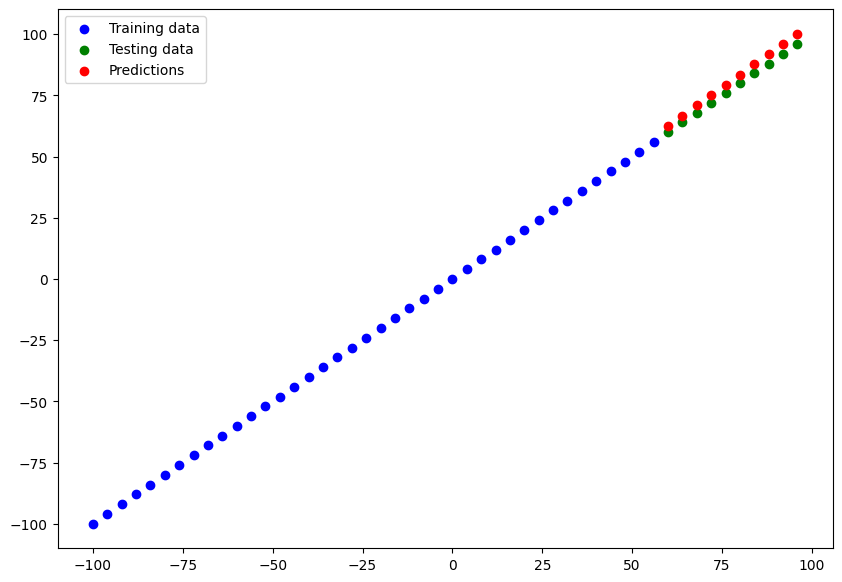

In [ ]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(x_test)
plot_predictions(predictions=y_preds_1)

In [ ]:
tf.constant(y_preds_1) , tf.squeeze(y_preds_1)

#squeeze reduce the dimension by 1

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[ 62.621384],
        [ 66.796165],
        [ 70.97095 ],
        [ 75.14573 ],
        [ 79.3205  ],
        [ 83.495285],
        [ 87.67007 ],
        [ 91.84484 ],
        [ 96.01962 ],
        [100.194405]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 62.621384,  66.796165,  70.97095 ,  75.14573 ,  79.3205  ,
         83.495285,  87.67007 ,  91.84484 ,  96.01962 , 100.194405],
       dtype=float32)>)

In [ ]:

# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(3.4078948), np.float32(11.865768))

In [ ]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1).numpy()
mse_1 = mse(y_test, y_preds_1).numpy()
mae_1, mse_1

(array([2.6213837, 2.7961655, 2.9709473, 3.145729 , 3.3205032, 3.495285 ,
        3.6700668, 3.844841 , 4.019623 , 4.1944046], dtype=float32),
 array([ 6.871652 ,  7.8185415,  8.826528 ,  9.895612 , 11.025742 ,
        12.217017 , 13.469391 , 14.782803 , 16.157368 , 17.593029 ],
       dtype=float32))

**model_2 **

In [ ]:
tf.random.set_seed(42)

#build the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_2.compile(loss=tf.keras.losses.mae,
                metrics=["mse"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_2.fit(x_train, y_train, epochs=100)
# Your model expects input with an extra dimension (e.g., (batch, timesteps, channels)), but x_train is missing it
# Working Code: tf.expand_dims(x_train, axis=-1) adds the missing dimension (e.g., from (1000, 10) to (1000, 10, 1)).

#(Example: If your first layer is Conv1D, it needs 3D input—so your fix is correct!)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 44.0957 - mse: 2945.8267 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 35.1521 - mse: 1745.4071
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.8021 - mse: 201.4409
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 16.3310 - mse: 372.8628
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 19.3679 - mse: 561.4953
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 23.0723 - mse: 801.8543
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 29.2418 - mse: 1206.1708
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.7137 - mse: 151.7426
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 16.7516 - mse: 398.4618
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 20.1319 - mse: 635.7877
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 36.2031 - mse: 1887.1552
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.8452 - mse: 168.0194
Epoch 13/10

In [ ]:
model_2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
x_train.shape

TensorShape([40])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


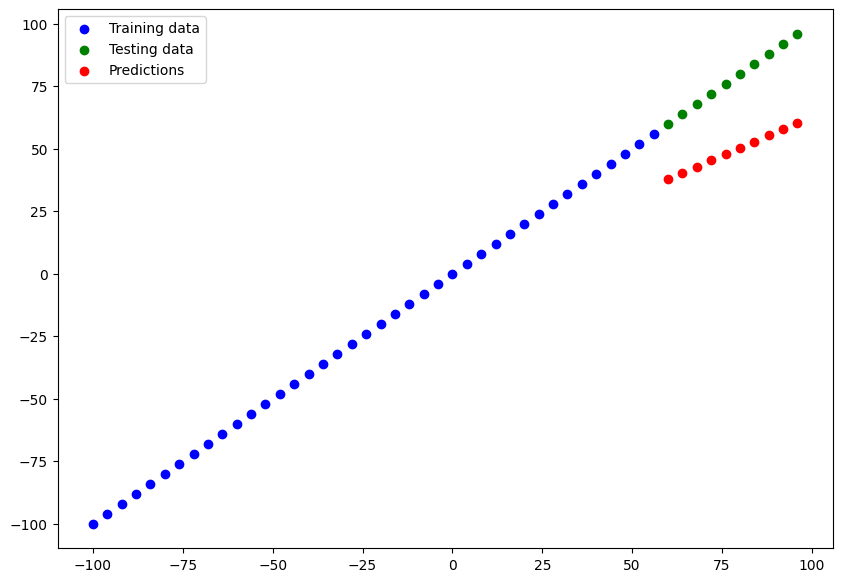

In [ ]:
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions=y_preds_2)

#red dots should be plot close to the green dots in order to claim a better model

In [ ]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([22.239548, 23.719826, 25.200108, 26.680397, 28.160675, 29.640957,
        31.121235, 32.601517, 34.0818  , 35.56208 ], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 494.59747,  562.6301 ,  635.0454 ,  711.84357,  793.0236 ,
         878.5863 ,  968.53125, 1062.8589 , 1161.569  , 1264.6616 ],
       dtype=float32)>)

Model_3

 2 layers and 500 epochs

In [ ]:
tf.random.set_seed(42)

#build the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_3.compile(loss=tf.keras.losses.mae,
                metrics=["mae"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_3.fit(x_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 57.6860 - mae: 57.6860 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 42.7938 - mae: 42.7938
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 35.0361 - mae: 35.0361
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 44.7291 - mae: 44.7291 
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 12.5747 - mae: 12.5747
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 13.5030 - mae: 13.5030
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 17.1939 - mae: 17.1939
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 20.2554 - mae: 20.2554
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 24.7497 - mae: 24.7497 
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 23.1955 - mae: 23.1955
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.0207 - mae: 8.0207
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 13.0713 - mae: 13.0713
Epoch 13/500
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


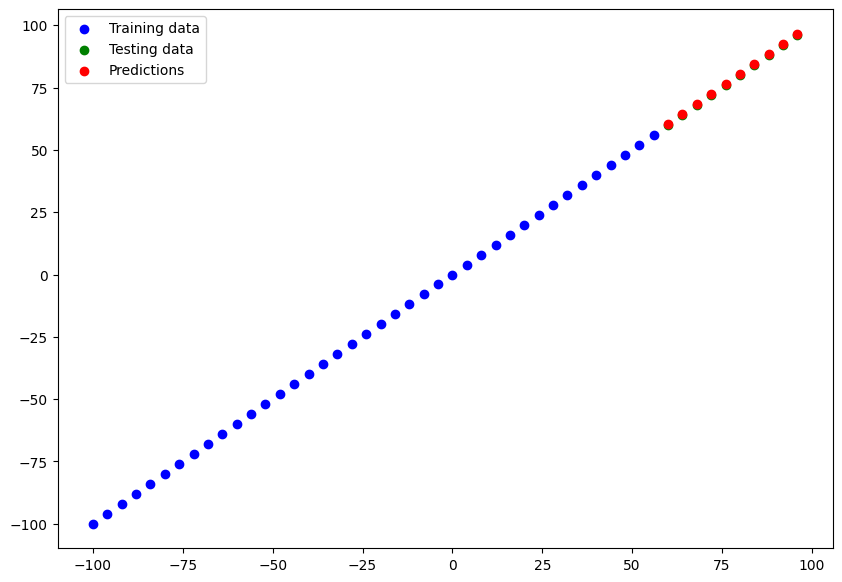

In [ ]:
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions=y_preds_3)

In [ ]:
# Calculate model_2 metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.33769608, 0.3635788 , 0.38945007, 0.41532898, 0.44120026,
        0.46707153, 0.4929428 , 0.5188217 , 0.544693  , 0.57056427],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.11403864, 0.13218954, 0.15167136, 0.17249817, 0.19465767,
        0.21815582, 0.24299261, 0.26917598, 0.29669046, 0.32554358],
       dtype=float32)>)

**Comparing results**

Now we've got results for 3 similar but slightly different results, let's compare them

In [ ]:
model_results = [["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mae_3]]


In [ ]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results


,model,mae,mse
0,model_1,"[2.6213837, 2.7961655, 2.9709473, 3.145729, 3....","[6.871652, 7.8185415, 8.826528, 9.895612, 11.0..."
1,model_2,"(tf.Tensor(22.239548, shape=(), dtype=float32)...","(tf.Tensor(494.59747, shape=(), dtype=float32)..."
2,model_3,"(tf.Tensor(0.33769608, shape=(), dtype=float32...","(tf.Tensor(0.33769608, shape=(), dtype=float32..."


from matplotlib import pyplot as plt
import seaborn as sns
all_results.groupby('model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)